###BASE PRICE PREDICTION (XGBOOST) + Dataset generation

In [ ]:
# PART 1: Install & Import
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [ ]:
VEHICLE_CONFIG = {
    'mini_truck':            {'max_weight_kg': 750,   'max_volume_m3': 4.5,  'kmpl': 18.0, 'base_wage': 600,  'wage_per_km': 3.5},
    'pickup_truck':          {'max_weight_kg': 1500,  'max_volume_m3': 8.0,  'kmpl': 14.0, 'base_wage': 800,  'wage_per_km': 4.5},
    '14ft_truck':            {'max_weight_kg': 4000,  'max_volume_m3': 22.0, 'kmpl': 10.0, 'base_wage': 1200, 'wage_per_km': 6.0},
    '17ft_truck':            {'max_weight_kg': 7000,  'max_volume_m3': 32.0, 'kmpl': 8.0,  'base_wage': 1500, 'wage_per_km': 7.5},
    '20ft_container':        {'max_weight_kg': 15000, 'max_volume_m3': 55.0, 'kmpl': 5.5,  'base_wage': 2000, 'wage_per_km': 10.0},
    '32ft_multi_axle_truck': {'max_weight_kg': 25000, 'max_volume_m3': 90.0, 'kmpl': 4.0,  'base_wage': 2800, 'wage_per_km': 13.0},
}

WEATHER_MULT    = {'clear': 1.00, 'cloudy': 1.03, 'rain': 1.10, 'heavy_rain': 1.18, 'storm': 1.30, 'fog': 1.12}
TIME_MULT       = {'standard': 1.00, 'express': 1.35, 'same_day': 1.75}
AREA_MULT       = {'urban': 1.00, 'semi_urban': 1.08, 'rural': 1.20, 'remote': 1.40}
WEATHER_ORD     = {'clear': 0, 'cloudy': 1, 'fog': 2, 'rain': 3, 'heavy_rain': 4, 'storm': 5}
TIME_ORD        = {'standard': 0, 'express': 1, 'same_day': 2}
VEHICLE_LIST    = list(VEHICLE_CONFIG.keys())
AREA_LIST       = ['urban', 'semi_urban', 'rural', 'remote']

In [ ]:
def generate_dataset(n=50000):
    rows = []
    dist_mean = {'mini_truck': 80, 'pickup_truck': 120, '14ft_truck': 250,
                 '17ft_truck': 400, '20ft_container': 600, '32ft_multi_axle_truck': 900}

    for _ in range(n):
        v   = np.random.choice(VEHICLE_LIST, p=[0.25, 0.20, 0.20, 0.15, 0.12, 0.08])
        cfg = VEHICLE_CONFIG[v]

        weight_kg   = round(np.random.uniform(10, cfg['max_weight_kg']), 2)
        volume_m3   = round(np.random.uniform(0.1, cfg['max_volume_m3']), 3)
        distance_km = round(min(np.random.exponential(dist_mean[v]) + 10, 3000), 1)
        fuel_price  = round(np.clip(np.random.normal(92, 5), 80, 110), 2)
        weather     = np.random.choice(list(WEATHER_MULT), p=[0.55, 0.15, 0.14, 0.08, 0.04, 0.04])
        time_window = np.random.choice(list(TIME_MULT),    p=[0.60, 0.28, 0.12])
        area_type   = np.random.choice(AREA_LIST,          p=[0.45, 0.30, 0.18, 0.07])
        is_fragile  = int(np.random.random() < 0.20)

        # Pricing
        fuel_cost       = (distance_km / cfg['kmpl']) * fuel_price
        driver_wage     = (cfg['base_wage'] + cfg['wage_per_km'] * distance_km) * np.random.uniform(0.9, 1.1)
        handling        = max(weight_kg, volume_m3 * 200) * 1.2
        fragile_extra   = handling * 0.15 if is_fragile else 0
        price           = (fuel_cost + driver_wage + handling + fragile_extra) \
                          * WEATHER_MULT[weather] * TIME_MULT[time_window] * AREA_MULT[area_type] \
                          * np.random.uniform(1.12, 1.22) * np.random.uniform(0.96, 1.04)

        rows.append({
            'vehicle_type':        VEHICLE_LIST.index(v),
            'distance_km':         distance_km,
            'weight_kg':           weight_kg,
            'volume_m3':           volume_m3,
            'fuel_cost_per_liter': fuel_price,
            'fuel_efficiency':     cfg['kmpl'],
            'is_fragile':          is_fragile,
            'time_window':         TIME_ORD[time_window],
            'weather':             WEATHER_ORD[weather],
            'area_type':           AREA_LIST.index(area_type),
            'base_price_inr':      round(price, 2),
        })

    return pd.DataFrame(rows)

df = generate_dataset()
print(df.shape)
print(df['base_price_inr'].describe().apply(lambda x: f"₹{x:,.0f}"))
df.head()

(50000, 11)
count     ₹50,000
mean      ₹20,530
std       ₹29,896
min          ₹862
25%        ₹3,961
50%        ₹9,377
75%       ₹23,817
max      ₹386,465
Name: base_price_inr, dtype: object


,vehicle_type,distance_km,weight_kg,volume_m3,fuel_cost_per_liter,fuel_efficiency,is_fragile,time_window,weather,area_type,base_price_inr
0,1,119.6,1426.56,5.883,90.83,14.0,0,1,0,1,6735.61
1,0,39.0,144.55,0.907,90.83,18.0,0,0,0,0,1248.21
2,2,190.5,3142.85,4.473,89.28,10.0,0,0,1,0,9780.92
3,0,20.4,516.33,2.037,92.55,18.0,0,0,0,2,1961.58
4,2,383.1,747.57,21.334,95.69,10.0,0,0,0,0,14371.05


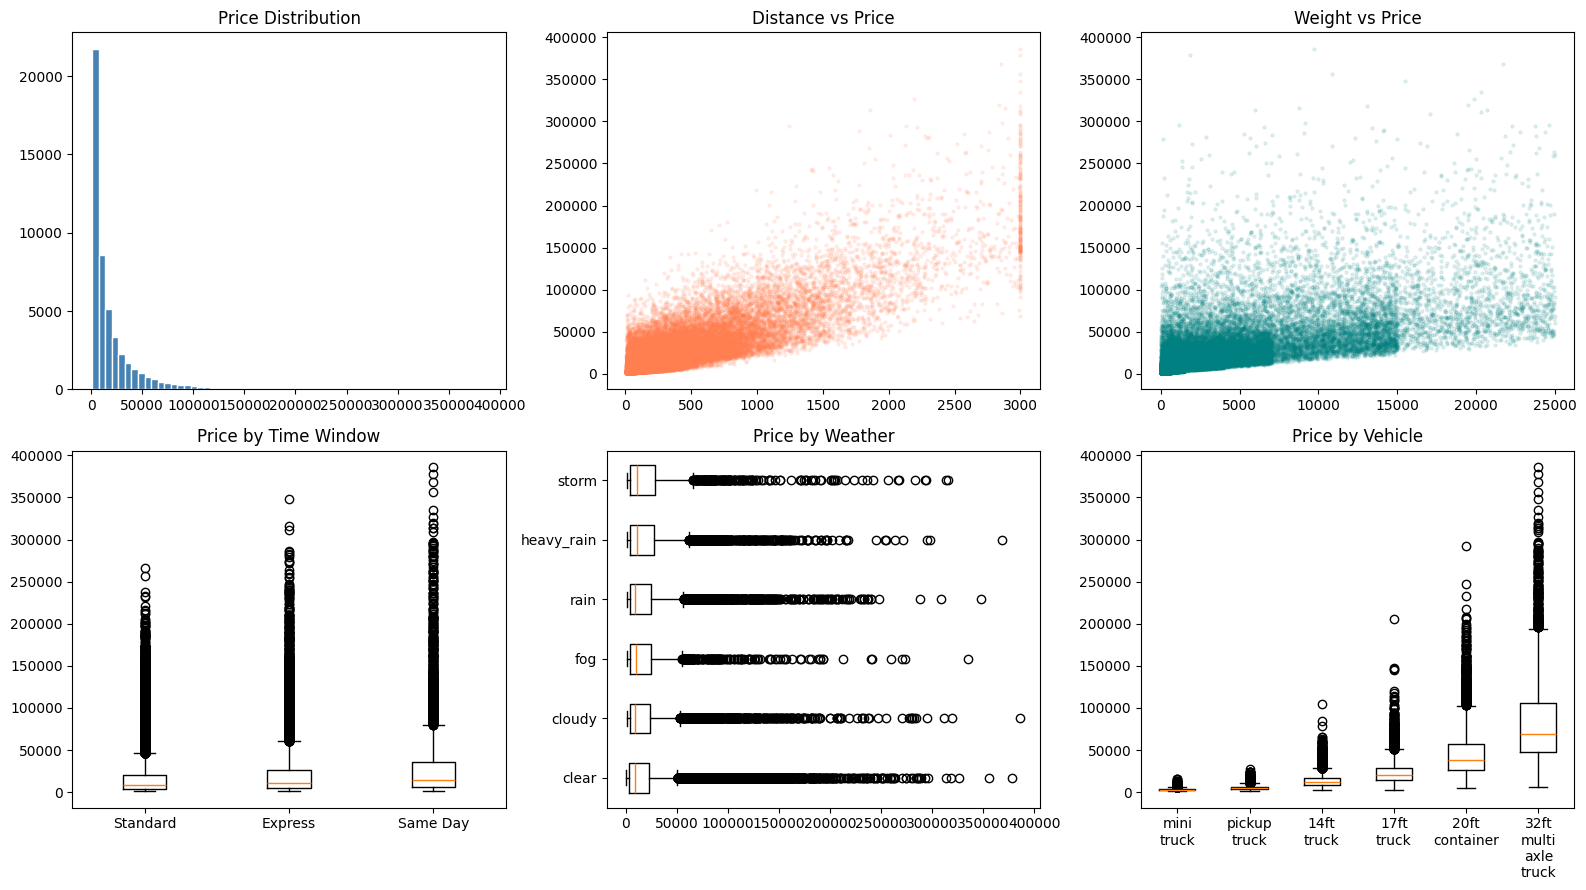

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0,0].hist(df['base_price_inr'], bins=60, color='steelblue', edgecolor='white')
axes[0,0].set_title('Price Distribution')

axes[0,1].scatter(df['distance_km'], df['base_price_inr'], alpha=0.1, s=5, color='coral')
axes[0,1].set_title('Distance vs Price')

axes[0,2].scatter(df['weight_kg'], df['base_price_inr'], alpha=0.1, s=5, color='teal')
axes[0,2].set_title('Weight vs Price')

axes[1,0].boxplot([df[df['time_window']==i]['base_price_inr'] for i in range(3)],
                   labels=['Standard','Express','Same Day'])
axes[1,0].set_title('Price by Time Window')

axes[1,1].boxplot([df[df['weather']==i]['base_price_inr'] for i in range(6)],
                   labels=list(WEATHER_ORD.keys()), vert=False)
axes[1,1].set_title('Price by Weather')

axes[1,2].boxplot([df[df['vehicle_type']==i]['base_price_inr'] for i in range(6)],
                   labels=[v.replace('_','\n') for v in VEHICLE_LIST])
axes[1,2].set_title('Price by Vehicle')

plt.tight_layout()
plt.show()

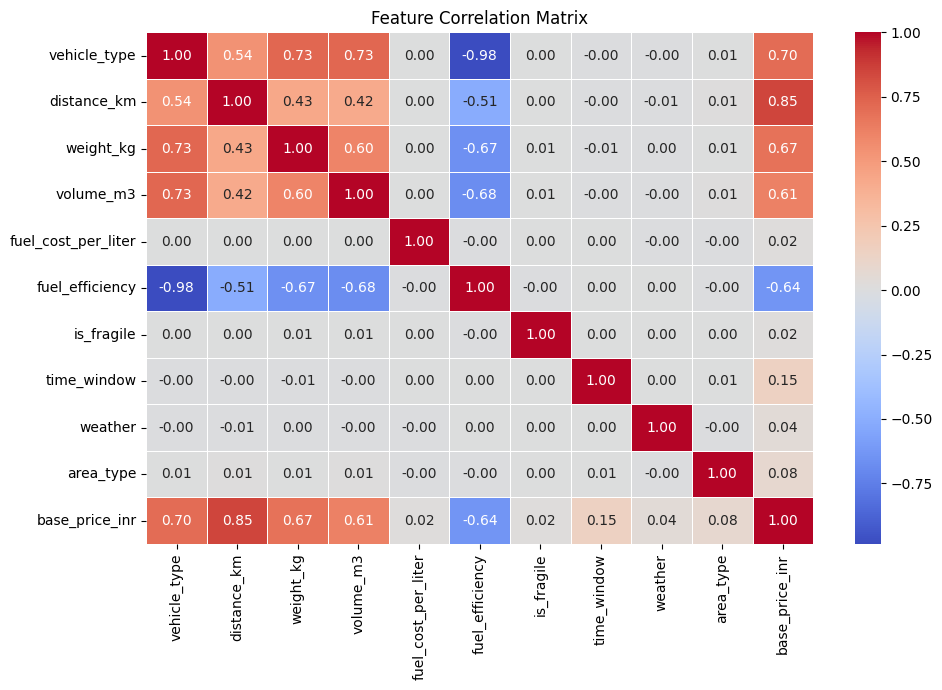

In [ ]:
cols = ['vehicle_type', 'distance_km', 'weight_kg', 'volume_m3',
        'fuel_cost_per_liter', 'fuel_efficiency', 'is_fragile',
        'time_window', 'weather', 'area_type', 'base_price_inr']

plt.figure(figsize=(10, 7))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

[0]	validation_0-mae:18153.98198
[50]	validation_0-mae:3335.70288
[99]	validation_0-mae:1980.50282
MAE  : ₹1,980.50
RMSE : ₹3,877.16
R²   : 0.9834
MAPE : 14.57%


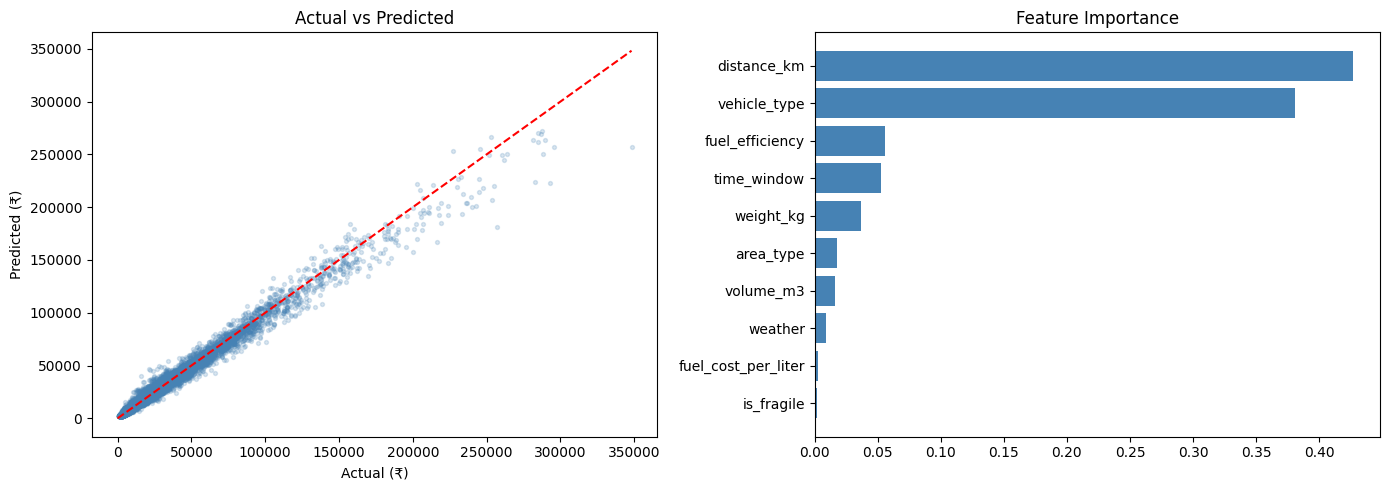

In [ ]:
FEATURES = ['vehicle_type', 'distance_km', 'weight_kg', 'volume_m3',
            'fuel_cost_per_liter', 'fuel_efficiency', 'is_fragile',
            'time_window', 'weather', 'area_type']

X_train, X_test, y_train, y_test = train_test_split(
    df[FEATURES], df['base_price_inr'], test_size=0.3, random_state=42)

model = xgb.XGBRegressor(
    n_estimators=100, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    early_stopping_rounds=20000, eval_metric='mae',
    random_state=42, n_jobs=-1, verbosity=0
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

y_pred = model.predict(X_test)
print(f"MAE  : ₹{mean_absolute_error(y_test, y_pred):,.2f}")
print(f"RMSE : ₹{np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")
print(f"MAPE : {np.mean(np.abs((y_test - y_pred)/y_test))*100:.2f}%")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.2, s=8, color='steelblue')
axes[0].plot([0, y_test.max()], [0, y_test.max()], 'r--')
axes[0].set(title='Actual vs Predicted', xlabel='Actual (₹)', ylabel='Predicted (₹)')

imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
axes[1].barh(imp.index, imp.values, color='steelblue')
axes[1].set_title('Feature Importance')

plt.tight_layout()
plt.show()

In [ ]:
def predict(vehicle_type, distance_km, weight_kg, volume_m3,
            fuel_cost_per_liter, time_window, weather, area_type, is_fragile):

    sample = pd.DataFrame([{
        'vehicle_type':        VEHICLE_LIST.index(vehicle_type),
        'distance_km':         distance_km,
        'weight_kg':           weight_kg,
        'volume_m3':           volume_m3,
        'fuel_cost_per_liter': fuel_cost_per_liter,
        'fuel_efficiency':     VEHICLE_CONFIG[vehicle_type]['kmpl'],
        'is_fragile':          int(is_fragile),
        'time_window':         TIME_ORD[time_window],
        'weather':             WEATHER_ORD[weather],
        'area_type':           AREA_LIST.index(area_type),
    }])

    price = model.predict(sample)[0]
    print(f"Predicted Price: ₹{price:,.2f}")
    return price

predict('14ft_truck', 350, 1200, 6.5, 93.5, 'express', 'rain', 'semi_urban', True)

Predicted Price: ₹16,463.25


np.float32(16463.254)